In [1]:
!pip install -q sentence-transformers #transformers scikit-learn

import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 90.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 68.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 73.8 MB/s eta 0:00:00


In [2]:
MODEL_NAME = "albert/albert-base-v2"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 🏷️ Humor categories con definizione
categories = {
    "Edgy Content": "Sex, taboos, death, shock",
    "Cultural Reference": "Politics, celebrities, pop culture",
    "Wordplay": "Puns, linguistic ambiguity",
    "Absurdity": "Illogical logic, surrealism, nonsense",
    "Relatable": "Everyday life, technology, relationships, self-irony",
    "Offensive Humor": "Insults, offensive, stereotypes, racism, sarcasm"
}

CATEGORY_NAMES = [
    "Edgy Content_LPR",
    "Cultural Reference_LPR",
    "Wordplay_LPR",
    "Absurdity_LPR",
    "Relatable_LPR",
    "Offensive Humor_LPR"
]

In [3]:
df = pd.read_csv("/kaggle/input/rated-short-jokes/aggregated_scores_LPR_10000.csv")

# Rinomina le colonne del dataframe rimuovendo gli spazi nei nomi delle categorie
df = df.rename(columns={col: col.replace(" ", "") for col in df.columns if "_LPR" in col})
CATEGORY_NAMES = [col.replace(" ", "") for col in CATEGORY_NAMES]

df = df.dropna(subset=["jokeText"] + CATEGORY_NAMES)
print(df.head())

# Normalizzazione per sigmoidea
# per visualizzare output in [0,10] moltiplicare le predizioni
df[CATEGORY_NAMES] = df[CATEGORY_NAMES] / 10.0

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
print(f"Train: {len(train_df)}, Test: {len(test_df)}")

                                            jokeText  EdgyContent_LPR  \
0  What do all battered women have in common? The...                8   
1  Who invented the North America? TEACHER: Sarah...                0   
2  I feel like this election ended up being a goo...                9   
3  What do you call a pile of kittens? A Meowntain\n                0   
4  I feel bad for people named John Smith. They p...                0   

   CulturalReference_LPR  Wordplay_LPR  Absurdity_LPR  Relatable_LPR  \
0                      0             0              0              1   
1                      8             0              6              7   
2                      9             0              0              1   
3                      0             9              0              2   
4                      9             0              1              8   

   OffensiveHumor_LPR  
0                   9  
1                   0  
2                  10  
3                   0  
4       

In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class JokeRegressor(nn.Module):
    def __init__(self, model_name=MODEL_NAME):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        self.regressor = nn.Sequential(
            nn.Linear(self.encoder.config.hidden_size, 128),
            nn.ReLU(),
            nn.Linear(128, len(CATEGORY_NAMES)),
            nn.Sigmoid()  # Output ∈ [0, 1]
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls_embedding = outputs.last_hidden_state[:, 0, :]
        return self.regressor(cls_embedding)


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/760k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [5]:
def encode_batch(texts, tokenizer, max_length=128):
    return tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors="pt"
    )


In [6]:
def train_model(model, train_df, tokenizer, epochs=3, batch_size=32, lr=2e-5):
    model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    texts = train_df["jokeText"].tolist()
    targets = train_df[CATEGORY_NAMES].values.astype(np.float32)

    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for i in tqdm(range(0, len(texts), batch_size)):
            batch_texts = texts[i:i+batch_size]
            batch_targets = torch.tensor(targets[i:i+batch_size]).to(DEVICE)

            enc = encode_batch(batch_texts, tokenizer)
            input_ids = enc["input_ids"].to(DEVICE)
            attention_mask = enc["attention_mask"].to(DEVICE)

            preds = model(input_ids, attention_mask)
            loss = loss_fn(preds, batch_targets)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"Epoch {epoch+1} - Loss: {total_loss:.4f}")


In [7]:
model = JokeRegressor()
train_model(model, train_df, tokenizer, epochs=5, batch_size=16, lr=2e-5)


2025-07-18 16:06:57.868167: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752854818.078052      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752854818.139338      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


model.safetensors:   0%|          | 0.00/47.4M [00:00<?, ?B/s]

100%|██████████| 500/500 [01:09<00:00,  7.19it/s]


Epoch 1 - Loss: 53.4731


100%|██████████| 500/500 [01:14<00:00,  6.74it/s]


...

Epoch 3 - Loss: 32.0816


100%|██████████| 500/500 [01:13<00:00,  6.79it/s]


Epoch 4 - Loss: 28.2848


100%|██████████| 500/500 [01:13<00:00,  6.79it/s]

Epoch 5 - Loss: 23.5435


In [8]:
model.eval()
test_texts = test_df["jokeText"].tolist()
test_targets = test_df[CATEGORY_NAMES].values.astype(np.float32)

all_preds = []
with torch.no_grad():
    for i in range(0, len(test_texts), 32):
        batch_texts = test_texts[i:i+32]
        enc = encode_batch(batch_texts, tokenizer)
        input_ids = enc["input_ids"].to(DEVICE)
        attention_mask = enc["attention_mask"].to(DEVICE)

        preds = model(input_ids, attention_mask).cpu().numpy()
        all_preds.append(preds)

all_preds = np.vstack(all_preds)


In [9]:
for i, name in enumerate(CATEGORY_NAMES):
    mse = mean_squared_error(test_targets[:, i], all_preds[:, i])
    mae = mean_absolute_error(test_targets[:, i], all_preds[:, i])
    print(f"{name} → MSE: {mse:.4f}, MAE: {mae:.4f}")


EdgyContent_LPR → MSE: 0.0710, MAE: 0.1558
CulturalReference_LPR → MSE: 0.0578, MAE: 0.1373
Wordplay_LPR → MSE: 0.0889, MAE: 0.1938
Absurdity_LPR → MSE: 0.1180, MAE: 0.2533
Relatable_LPR → MSE: 0.0557, MAE: 0.1757
OffensiveHumor_LPR → MSE: 0.0647, MAE: 0.1469



🔹 Joke 1:
If a stork brings white babies and a crow brings black babies, what brings no babies? A little Swallow.

  EdgyContent_LPR: GT = 0.00 | Pred = 0.42
  CulturalReference_LPR: GT = 0.10 | Pred = 0.07
  Wordplay_LPR: GT = 0.90 | Pred = 0.07
  Absurdity_LPR: GT = 0.80 | Pred = 0.33
  Relatable_LPR: GT = 0.00 | Pred = 0.13
  OffensiveHumor_LPR: GT = 0.00 | Pred = 0.60

🔹 Joke 2:
People are always mistaking things I say as racist. The other day, this guy thought I called him a 'sand nigger.' But what I said was, 'get out of the sand, nigger. Volleyball is a white man's sport.'

  EdgyContent_LPR: GT = 0.90 | Pred = 0.84
  CulturalReference_LPR: GT = 0.50 | Pred = 0.48
  Wordplay_LPR: GT = 0.00 | Pred = 0.09
  Absurdity_LPR: GT = 0.00 | Pred = 0.08
  Relatable_LPR: GT = 0.00 | Pred = 0.08
  OffensiveHumor_LPR: GT = 1.00 | Pred = 0.91

🔹 Joke 3:
I feel sorry for homeless gay people They have no closet to come out of

  EdgyContent_LPR: GT = 0.90 | Pred = 0.68
  CulturalReference_LPR:

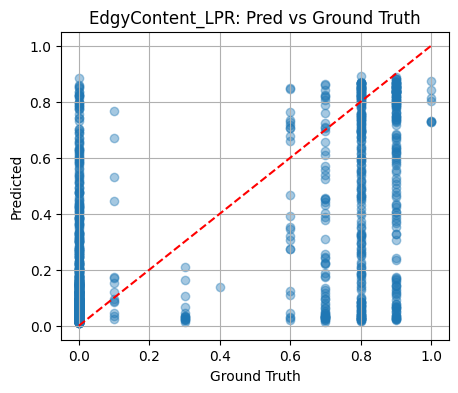

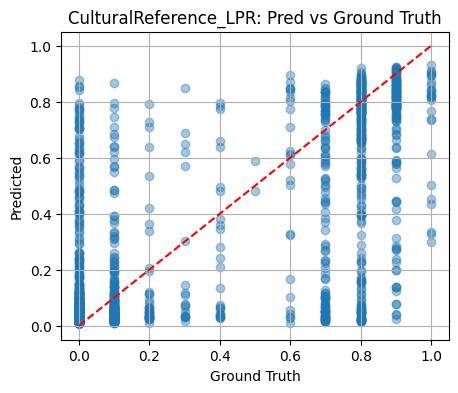

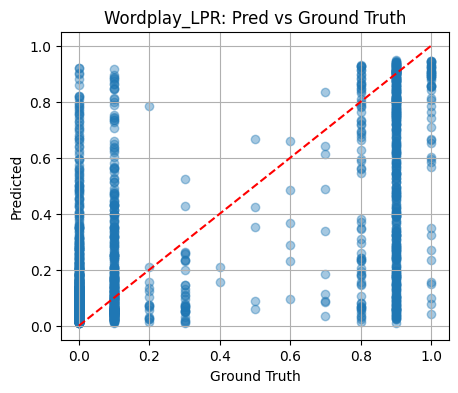

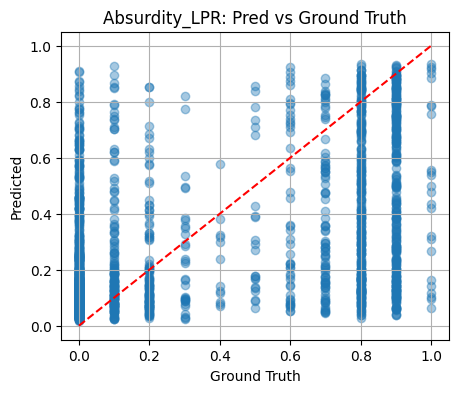

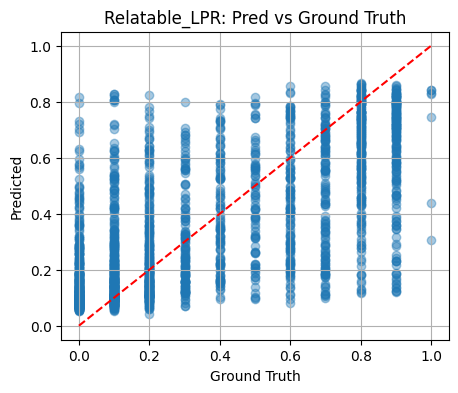

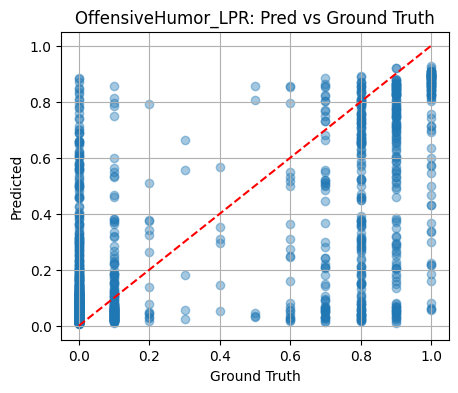

In [10]:
np.set_printoptions(precision=2)

# Conversione in DataFrame per visualizzazione semplice
results_df = pd.DataFrame({
    "jokeText": test_texts[:10],
    "Ground Truth": list(test_targets[:10]),
    "Predicted": list(all_preds[:10])
})

# Per ogni riga, stampa i valori reali e predetti
for i, row in results_df.iterrows():
    print(f"\n🔹 Joke {i+1}:")
    print(row["jokeText"])
    for j, cat in enumerate(CATEGORY_NAMES):
        print(f"  {cat}: GT = {row['Ground Truth'][j]:.2f} | Pred = {row['Predicted'][j]:.2f}")

import matplotlib.pyplot as plt

for i, cat in enumerate(CATEGORY_NAMES):
    plt.figure(figsize=(5, 4))
    plt.scatter(test_targets[:, i], all_preds[:, i], alpha=0.4)
    plt.plot([0, 1], [0, 1], color='red', linestyle='--')
    plt.xlabel("Ground Truth")
    plt.ylabel("Predicted")
    plt.title(f"{cat}: Pred vs Ground Truth")
    plt.grid(True)
    plt.show()


In [11]:
# Scegli il path dove salvare i pesi
MODEL_SAVE_PATH = "/kaggle/working/joke_regressor_state_dict.pt"

# Salva solo lo stato dei pesi (state_dict)
torch.save(model.state_dict(), MODEL_SAVE_PATH)
print(f"✅ Modello salvato su {MODEL_SAVE_PATH}")

✅ Modello salvato su /kaggle/working/joke_regressor_state_dict.pt


### Next

In [12]:
error()

NameError: name 'error' is not defined

In [ ]:
# da usare per miglioramento della generazione
def predict_scores(joke_texts, model, tokenizer):
    model.eval()
    enc = encode_batch(joke_texts, tokenizer)
    input_ids = enc["input_ids"].to(DEVICE)
    attention_mask = enc["attention_mask"].to(DEVICE)
    with torch.no_grad():
        preds = model(input_ids, attention_mask).cpu().numpy()
    return preds
